# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load Dataset

In [2]:
data = pd.read_csv('kelayakan-pendidikan-indonesia.csv', index_col=0)
data.head()

,Sekolah,Siswa,Mengulang,Putus Sekolah,Kepala Sekolah dan Guru(<S1),Kepala Sekolah dan Guru(≥ S1),Tenaga Kependidikan(SM),Tenaga Kependidikan(>SM),Rombongan Belajar,Ruang kelas(baik),Ruang kelas(rusak ringan),Ruang kelas(rusak sedang),Ruang kelas(rusak berat),Unnamed: 14
Provinsi,,,,,,,,,,,,,,
Prov. D.K.I. Jakarta,2224,756455,1202,869,1089,38305,6967,1569,27830,23320,3886,717,345,NaN
Prov. Jawa Barat,19553,4487262,4778,5675,5007,209252,27487,3353,169704,59592,46006,34432,14397,NaN
Prov. Jawa Tengah,18618,2595050,6909,2399,2337,167535,21325,2473,127266,51050,42356,26321,13457,NaN
Prov. D.I. Yogyakarta,1846,270610,357,75,326,19771,4536,866,13719,8217,3878,1827,548,NaN
Prov. Jawa Timur,18980,2530849,4694,3327,2950,180465,21116,3818,134724,58679,42896,24218,14389,NaN


# Check Missing Value

In [3]:
data.isnull().sum()

Sekolah                           0
Siswa                             0
Mengulang                         0
Putus Sekolah                     0
Kepala Sekolah dan Guru(<S1)      0
Kepala Sekolah dan Guru(≥ S1)     0
Tenaga Kependidikan(SM)           0
Tenaga Kependidikan(>SM)          0
Rombongan Belajar                 0
Ruang kelas(baik)                 0
Ruang kelas(rusak ringan)         0
Ruang kelas(rusak sedang)         0
Ruang kelas(rusak berat)          0
Unnamed: 14                      39
dtype: int64

# Handling Missing Value

In [4]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data.head()

,Sekolah,Siswa,Mengulang,Putus Sekolah,Kepala Sekolah dan Guru(<S1),Kepala Sekolah dan Guru(≥ S1),Tenaga Kependidikan(SM),Tenaga Kependidikan(>SM),Rombongan Belajar,Ruang kelas(baik),Ruang kelas(rusak ringan),Ruang kelas(rusak sedang),Ruang kelas(rusak berat),Unnamed: 14
Provinsi,,,,,,,,,,,,,,
Prov. D.K.I. Jakarta,2224,756455,1202,869,1089,38305,6967,1569,27830,23320,3886,717,345,NaN
Prov. Jawa Barat,19553,4487262,4778,5675,5007,209252,27487,3353,169704,59592,46006,34432,14397,NaN
Prov. Jawa Tengah,18618,2595050,6909,2399,2337,167535,21325,2473,127266,51050,42356,26321,13457,NaN
Prov. D.I. Yogyakarta,1846,270610,357,75,326,19771,4536,866,13719,8217,3878,1827,548,NaN
Prov. Jawa Timur,18980,2530849,4694,3327,2950,180465,21116,3818,134724,58679,42896,24218,14389,NaN


# Dataframe Baru

In [5]:
data_pca = data[[
    'Sekolah',
    'Siswa',
    'Kepala Sekolah dan Guru(<S1)',
    'Kepala Sekolah dan Guru(≥ S1)',
    'Tenaga Kependidikan(SM)',
    'Tenaga Kependidikan(>SM)',
    'Rombongan Belajar',
    'Ruang kelas(baik)',
]]

data_pca.head()

,Sekolah,Siswa,Kepala Sekolah dan Guru(<S1),Kepala Sekolah dan Guru(≥ S1),Tenaga Kependidikan(SM),Tenaga Kependidikan(>SM),Rombongan Belajar,Ruang kelas(baik)
Provinsi,,,,,,,,
Prov. D.K.I. Jakarta,2224,756455,1089,38305,6967,1569,27830,23320
Prov. Jawa Barat,19553,4487262,5007,209252,27487,3353,169704,59592
Prov. Jawa Tengah,18618,2595050,2337,167535,21325,2473,127266,51050
Prov. D.I. Yogyakarta,1846,270610,326,19771,4536,866,13719,8217
Prov. Jawa Timur,18980,2530849,2950,180465,21116,3818,134724,58679


# Change Columns

In [6]:
data_pca.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

data_scaled_df = pd.DataFrame(data_scaled, columns=data_pca.columns, index=data_pca.index)
print('data setelah distandarisasi:')
data_scaled_df.head()

data setelah distandarisasi:


,X1,X2,X3,X4,X5,X6,X7,X8
Provinsi,,,,,,,,
Prov. D.K.I. Jakarta,-0.331971,0.163269,-0.222164,-0.040724,0.197258,0.718280,-0.040494,0.775155
Prov. Jawa Barat,3.278182,4.532546,3.682491,3.535141,3.589580,2.655072,3.819924,3.266198
Prov. Jawa Tengah,3.083394,2.316511,1.021585,2.662506,2.570892,1.699704,2.665178,2.679561
Prov. D.I. Yogyakarta,-0.410720,-0.405721,-0.982565,-0.428418,-0.204630,-0.044929,-0.424457,-0.262071
Prov. Jawa Timur,3.158809,2.241323,1.632497,2.932976,2.536340,3.159897,2.868111,3.203496


# EDA After Standarisation

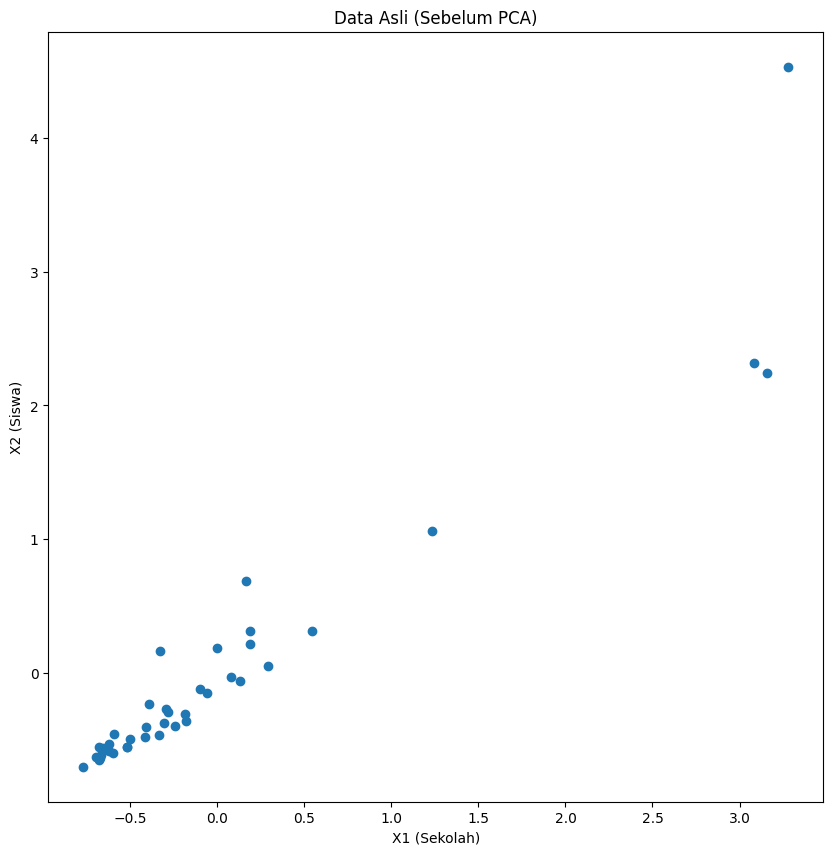

In [7]:
plt.figure(figsize=(10, 10))
plt.plot(data_scaled_df['X1'] ,data_scaled_df['X2'], 'o', label='Data Asli')
plt.xlabel('X1 (Sekolah)')
plt.ylabel('X2 (Siswa)')
plt.title('Data Asli (Sebelum PCA)')
plt.show()

# Uji Kelayakan PCA Menggunakan KMO

In [8]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(data_scaled_df)
print(f'KMO Model: {kmo_model}')

KMO Model: 0.7780905430339631


d:\KULIAH\semester 2\prak model statistik\Proyek\.env\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


# PCA

In [9]:
pca = PCA()
pca.fit(data_scaled_df)


eigen_values = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

pca_sumary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigen_values))],
    'Eigen Value': eigen_values,
    'Explained Variance Ratio': explained_variance_ratio,
    'Cumulative Explained Variance': cumulative_explained_variance
})

pca_sumary.head()

,Principal Component,Eigen Value,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,7.603752,0.926098,0.926098
1,PC2,0.328909,0.040059,0.966157
2,PC3,0.168584,0.020533,0.986690
3,PC4,0.053837,0.006557,0.993247
4,PC5,0.036633,0.004462,0.997709


In [10]:
loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(eigen_values))],
    index=data_scaled_df.columns
)

print('Loading Matrix:')
loading_matrix.head()

Loading Matrix:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
X1,0.360418,-0.086894,-0.308404,-0.518093,-0.348787,-0.191777,-0.434347,-0.389778
X2,0.358042,0.068539,-0.325791,0.749886,0.157137,-0.236975,-0.109377,-0.325312
X3,0.315005,0.875816,0.332498,-0.111623,0.071577,0.025680,-0.067038,-0.020665
X4,0.365889,-0.032850,-0.126959,-0.199121,-0.058288,-0.241754,0.861052,-0.077627
X5,0.360641,-0.137588,0.214079,0.271076,-0.619108,0.586206,0.061292,0.031727


# Scores PCA

In [12]:
score = pd.DataFrame(
    pca.transform(data_scaled_df),
    columns=[f'PC{i+1}' for i in range(len(eigen_values))],
    index=data_scaled_df.index
)

print('proyeksi data ke ruang komponen utama:')
score.head()

proyeksi data ke ruang komponen utama:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Provinsi,,,,,,,,
Prov. D.K.I. Jakarta,0.433735,-0.606746,0.425250,0.222903,0.654519,0.360379,0.003898,-0.012077
Prov. Jawa Barat,10.026946,0.927475,-0.545330,0.911241,-0.056277,-0.107054,-0.023014,0.003452
Prov. Jawa Tengah,6.680772,-0.854023,-1.055006,-0.343853,-0.384317,0.213409,0.016761,-0.030689
Prov. D.I. Yogyakarta,-1.098154,-0.740746,0.063662,0.100378,-0.005485,0.078210,-0.005671,-0.007618
Prov. Jawa Timur,7.718816,-1.032444,0.030856,-0.670636,0.255400,-0.089758,-0.069428,0.023416


# Visualisasi Scree plot

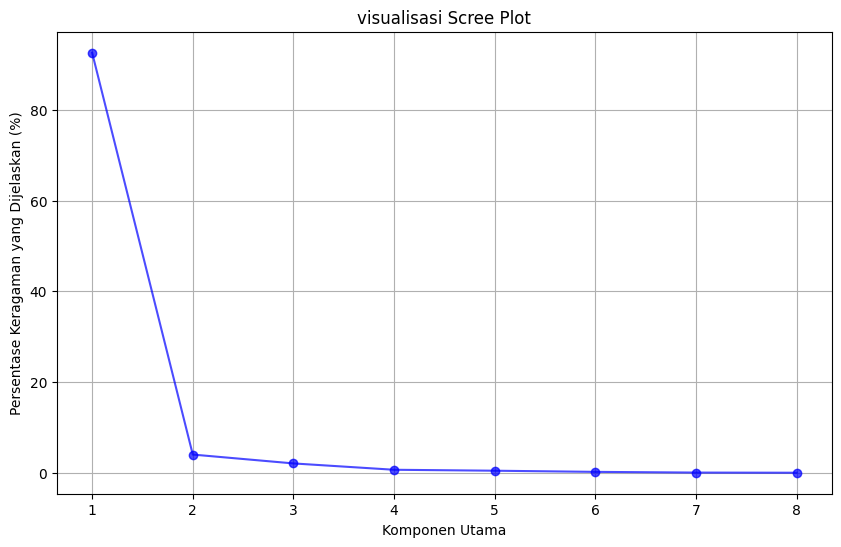

In [15]:
explained_variance_ratio = pca.explained_variance_ratio_
explained_var_percentage = explained_variance_ratio * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_percentage) + 1), explained_var_percentage, alpha=0.7, color='blue', marker='o')
plt.xlabel('Komponen Utama')
plt.ylabel('Persentase Keragaman yang Dijelaskan (%)')
plt.title('visualisasi Scree Plot')
plt.xticks(range(1, len(explained_var_percentage) + 1))
plt.grid()
plt.show()

# Visualisasi  PCA Individuals Plot

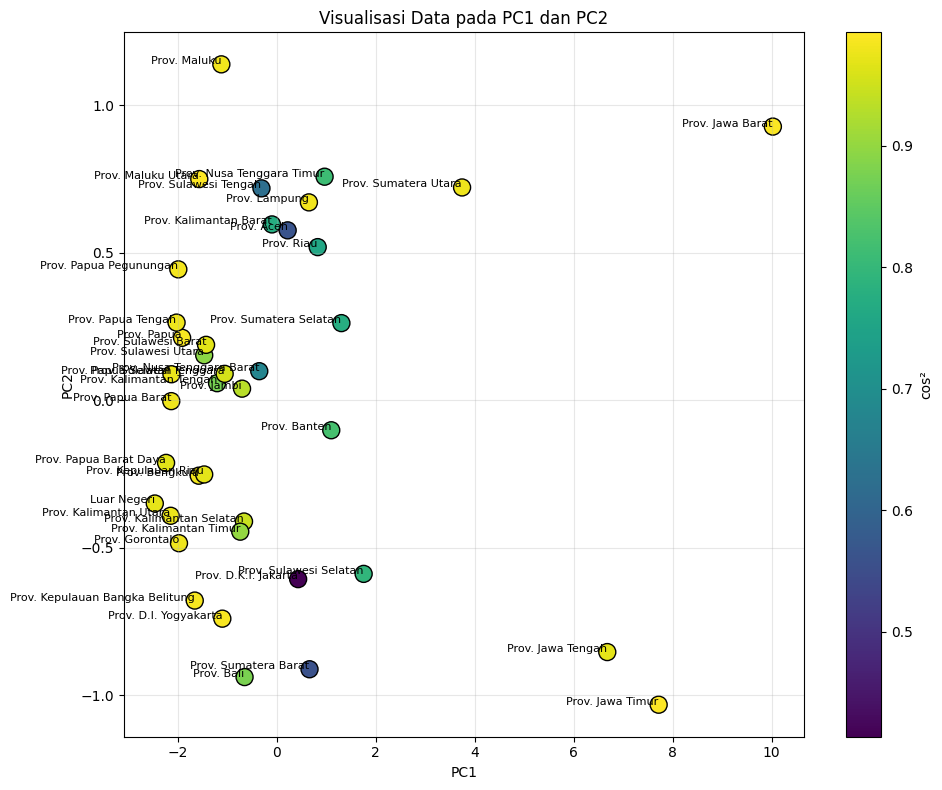

In [16]:
pc1 = score['PC1']
pc2 = score['PC2']

squared_list = np.sum(score.values**2, axis=1)
cos2 = (pc1**2 + pc2**2) / squared_list
plt.figure(figsize=(10,8))

#scatter
scatter = plt.scatter(pc1, pc2, c=cos2, s=150, edgecolors='black')
plt.colorbar(scatter, label='cos²')

for idx, txt in enumerate(score.index):
    plt.annotate(txt, (pc1.iloc[idx], pc2.iloc[idx]), fontsize=8, ha='right')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi Data pada PC1 dan PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()